# Weighted Effect CDF Validation

In [199]:
import os
from dotenv import load_dotenv

import geopandas as gpd
import pandas as pd
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr
import math
import matplotlib.colors as mcolors

import cartopy.crs as ccrs

import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

import cartopy.crs as ccrs
from scipy.interpolate import interp1d
from shapely import box

from xhistogram.xarray import histogram

In [140]:
def pop_weight_sum(da, rate=True, age_weight=True):
    if age_weight:
        pop_weight = xr.concat(
            [socioeconomics['pop0to4'], socioeconomics['pop5to64'], socioeconomics['pop65plus']],
            dim=pd.Index(['age0to4', 'age5to64', 'age65plus'], name='age_cohort')
        )
        age_weighted_total = da * pop_weight / 100000

        if rate:
            age_weighted_total = age_weighted_total * 100000 / socioeconomics['pop']
        regional_sum = age_weighted_total.sum(dim='age_cohort')
        regional_sum.name = "age_weighted_effect"
    else:
        regional_sum = da.sel(age_cohort='age65plus')
        regional_sum.name = "age_weighted_effect"
        
    return regional_sum

def compute_impact(projected, hotonly = False, rate = False, age_weight = True):
    if hotonly:
        #Hotonly
        _baseline = (
            projected["/baseline_hotonly"]["effect"]
            .sel(time=baseline_period)
            .groupby("time.month")
            .mean()
        )
        _forecast = (
            projected["/forecast_hotonly"]["effect"].mean(dim="number").groupby("time.month").mean()
        )
        impact = _forecast - _baseline
        impact.name = "impact"
        impact.attrs["long_name"] = "Temperature mortality impact"
        impact.attrs["units"] = "Deaths per 100,000 people"
        impact.attrs['hotonly'] = True
        regional_sum = pop_weight_sum(impact, rate=rate, age_weight=age_weight)
    else:
        ## Net
        _baseline = (
            projected["/baseline"]["effect"]
            .sel(time=baseline_period)
            .groupby("time.month")
            .mean()
        )
        _forecast = (
            projected["/forecast"]["effect"].mean(dim="number").groupby("time.month").mean()
        )
        impact = _forecast - _baseline
        impact.name = "impact"
        impact.attrs["long_name"] = "Temperature mortality impact"
        impact.attrs["units"] = "Deaths per 100,000 people"
        impact.attrs['hotonly'] = False
        regional_sum = pop_weight_sum(impact, rate=rate, age_weight=age_weight)
    return regional_sum

In [188]:
load_dotenv(dotenv_path="/home/emily_zuetell/projects/poreallas/env_local.env")
DATA_DIR = "/home/emily_zuetell/projects/poreallas/scripts/data/"
EFFECTS_URI = os.getenv("POREALLAS_EFFECTS_URI")
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

In [272]:
projected = xr.open_datatree(os.path.join(DATA_DIR,"v20260702/effects_net_hot_cold_gmfd_biasadjusted.zarr"))
socioeconomics =  xr.open_zarr(SOCIOECONOMICS_URI).sel(year = 2026)

_max_year = projected["/baseline"]["time"].max().dt.year.item()
_min_year = _max_year - 30
baseline_period = slice(str(_min_year), str(_max_year))

/tmp/ipykernel_28325/1508317071.py:1: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  projected = xr.open_datatree(os.path.join(DATA_DIR,"v20260702/effects_net_hot_cold_gmfd_biasadjusted.zarr"))
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [189]:
# Climate Data by Impact Regopm
forecast_gmfd = xr.open_zarr(os.path.join(DATA_DIR, "daily_forecast_GMFD_tas.zarr"))
reanlysis_gmfd = xr.open_zarr(os.path.join(DATA_DIR, "daily_reanalysis_GMFD_tas.zarr"))

#Intermediate Betas/MMT from Project.Py
betas_mmt = xr.open_zarr(os.path.join(DATA_DIR, "beta_mmt_GMFD.zarr"))

In [144]:
forecast_local = forecast_gmfd['tas']
reanalysis_local = reanlysis_gmfd['tas']
months = np.unique(forecast_local.time.month.values)

In [145]:
def weighted_cdf(data, n_bins=50):
    #Normalize cdf of daily temps (over year/ensemble) to 1 month
    counts, edges = np.histogram(data, bins=n_bins, density=True)
    bin_centers = (edges[:-1] + edges[1:]) / 2
    response_weights = response_interp(bin_centers)
    weighted = counts * response_weights
    cdf = np.cumsum(weighted * np.diff(edges))  # normalize by bin width
    return bin_centers, cdf

In [ ]:
region_filter = 'CHN.11.109.767'
hotonly = False
cdf_data = {}
max_cdf = 0
month = 8


forecast_local_month = forecast_local.sel(region = region_filter, time=forecast_local.time.dt.month == month)
reanalysis_local_month = reanalysis_local.sel(region = region_filter, time=reanalysis_local.time.dt.month == month)


ref_vals = betas_mmt['mmt'].sel(region=region_filter).sel(age_cohort='age65plus') + 273.15
betas = betas_mmt['beta_hotonly'] if hotonly else betas_mmt['beta']
da_temp_bins = betas.sel(region=region_filter).sel(age_cohort='age65plus')
da_temp_bins['tas_bin'] = da_temp_bins['tas_bin'] + 273.15

#era5_centers, era5_cdf = weighted_cdf(reanalysis_local_month.values.flatten())
#fc_centers, fc_cdf = weighted_cdf(forecast_local_month.values.flatten())

#data = reanalysis_local_month
#counts, edges = np.histogram(data, bins=50, density=False)
#bin_centers = (edges[:-1] + edges[1:]) / 2
#response_weights = response_interp(bin_centers)
#weighted = counts * response_weights/12
#cdf_reanalysis = np.cumsum(weighted)

data = forecast_local_month
counts, edges = np.histogram(data, bins=da_temp_bins['tas_bin'].values, density=False)

weighted = counts/51 * response_weights
cdf_forecast = np.cumsum(weighted)


In [266]:
data = forecast_local_month

response_weights = betas.sel(region = region_filter).sel(age_cohort = 'age65plus').values

bins = da_temp_bins['tas_bin'].values
edges = np.concatenate([bins, [bins[-1] + np.diff(bins)[-1]]])
counts, edges = np.histogram(data, bins=edges, density=False)

weighted = counts * response_weights * (31/counts.sum())
cdf_forecast = np.cumsum(weighted)

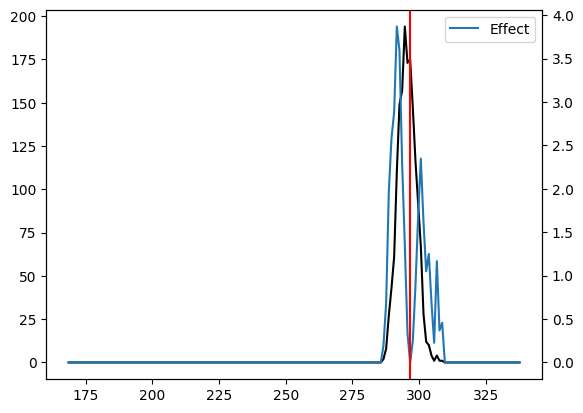

In [267]:
plt.plot(bins, counts, color = 'black', label = 'Hist')
plt.twinx()
plt.plot(bins, weighted, label = "Effect")
plt.axvline(ref_vals.values, color = 'red')
plt.legend()

In [245]:
regional_sum = compute_impact(projected, hotonly = hotonly, rate = True, age_weight = False)
regional_sum_month = regional_sum.sel(month = month)

In [152]:
regional_sum_month.sel(region = region_filter).values

array(6.657236, dtype=float32)

In [246]:
_forecast = (
            projected["/forecast"]["effect"].mean(dim="number").groupby("time.month").mean()
        )

In [247]:
test_f = _forecast.sel(region = region_filter, age_cohort = 'age65plus')

In [248]:
_baseline = (
            projected["/baseline"]["effect"]
            .sel(time=baseline_period)
            .groupby("time.month")
            .mean()
        )
        

In [249]:
test_b = _baseline.sel(region = region_filter, age_cohort = 'age65plus')

In [250]:
test_f.sel(month = 8).values

array(33.582436, dtype=float32)

In [251]:
test_b.sel(month = 8).values

array(26.9252, dtype=float32)

In [159]:
test_f-test_b

<xarray.DataArray 'effect' (month: 6)> Size: 24B
array([-22.303886 ,  -5.3381653,  10.150293 ,   6.657236 , -18.289772 ,
        -9.969254 ], dtype=float32)
Coordinates:
  * month       (month) int64 48B 5 6 7 8 9 10
    region      StringDType() 16B 'CHN.11.109.767'
    age_cohort  StringDType() 16B 'age65plus'
Attributes:
    units:      deaths per 100,000 people
    long_name:  Temperature mortality